In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import gdown
import os

In [3]:
def img_details(name, img, shape=None, i=None, cmap=None, show=1):
    if shape and i is not None:
        plt.subplot(shape[0], shape[1], i)
        show = None
    if cmap is None:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(f'{name}{img.shape}')
    if show is not None:
        plt.show()
    plt.tight_layout()

In [4]:
def detect_coins(img):
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(img, dtype=np.uint8)
    cv2.drawContours(mask, contours, -1, (255), thickness=cv2.FILLED)
    return edges, mask

In [8]:
url = r"D:\COLLEGE\COMPUTER VISION\IMAGES\One Rupee.jpg"
img = plt.imread(url)
edges, mask = detect_coins(img)

In [9]:
def print_coin_detection():
    s = (1, 3)
    plt.figure(figsize=(15, 5))
    img_details('Original', img, s, 1)
    img_details('Edges', edges, s, 2)
    img_details('Detected Coins', mask, s, 3)
    plt.show()

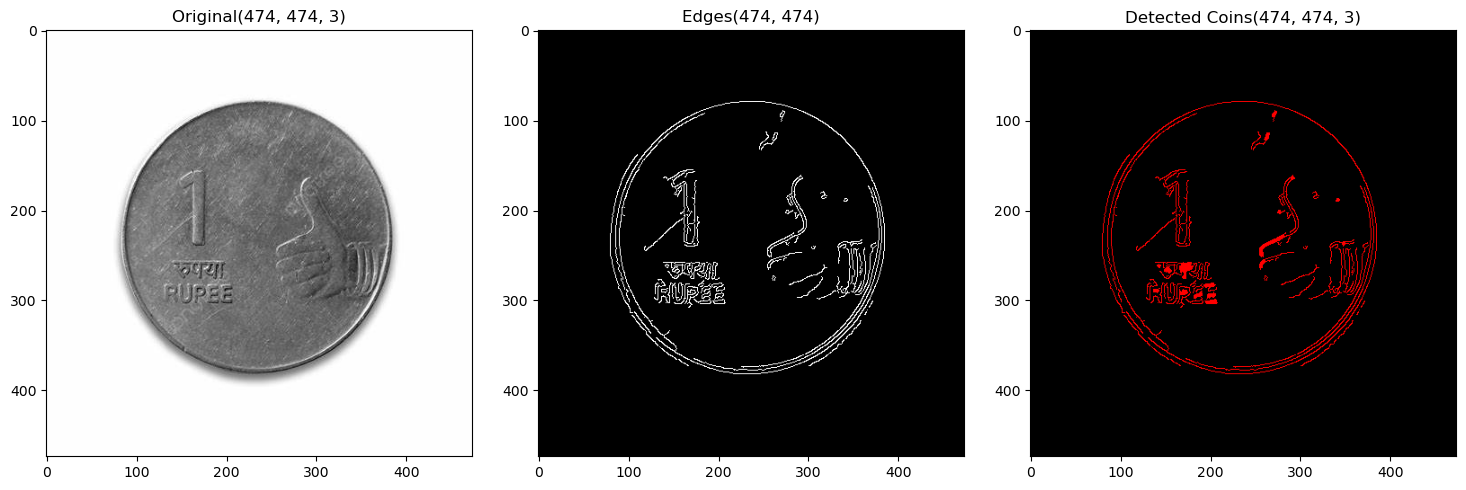

In [10]:
print_coin_detection()